# Agentic RAG

RAG Agent는 Retriever를 Tool로 등록해서 Agent가 **검색 여부를 판단**한다. 하지만 검색 자체는 여전히 1회성이다. 검색 결과가 부정확해도 그대로 답변에 사용하고, 쿼리가 검색에 부적합해도 수정 없이 넘긴다.

Agentic RAG는 **검색 파이프라인 자체**를 에이전트화한다. 검색 결과를 평가하고, 부족하면 쿼리를 재작성해서 다시 검색하고, 답변 생성 후에도 자체 검증을 거친다. 즉, 검색 → 평가 → 재시도의 **자율적인 루프**를 구성하는 것이 핵심이다.

| 구분 | RAG Agent | Agentic RAG |
|----|-----------|-------------|
| 핵심 아이디어 | Agent가 RAG를 **도구로 사용** | RAG 흐름 자체가 **에이전트화** |
| 검색 횟수 | 보통 1회 | 필요에 따라 반복 |
| 자율성 | Agent 레벨에서 결정 (검색 여부) | 검색 레벨에서도 자율 판단 (쿼리 재작성, 관련성 평가) |
| 쿼리 수정 | 사용자 질문 그대로 | 동적으로 재작성 |
| 적합한 상황 | 단순 질문, 빠른 응답 | 복잡한 질문, 높은 정확도 |

In [ ]:
from dotenv import load_dotenv

load_dotenv()

## 실습: Agentic RAG 구현

Reflection 패턴의 "자기 평가 → 수정 → 재시도" 루프를 RAG 파이프라인에 적용한다.

구현할 그래프 구조:

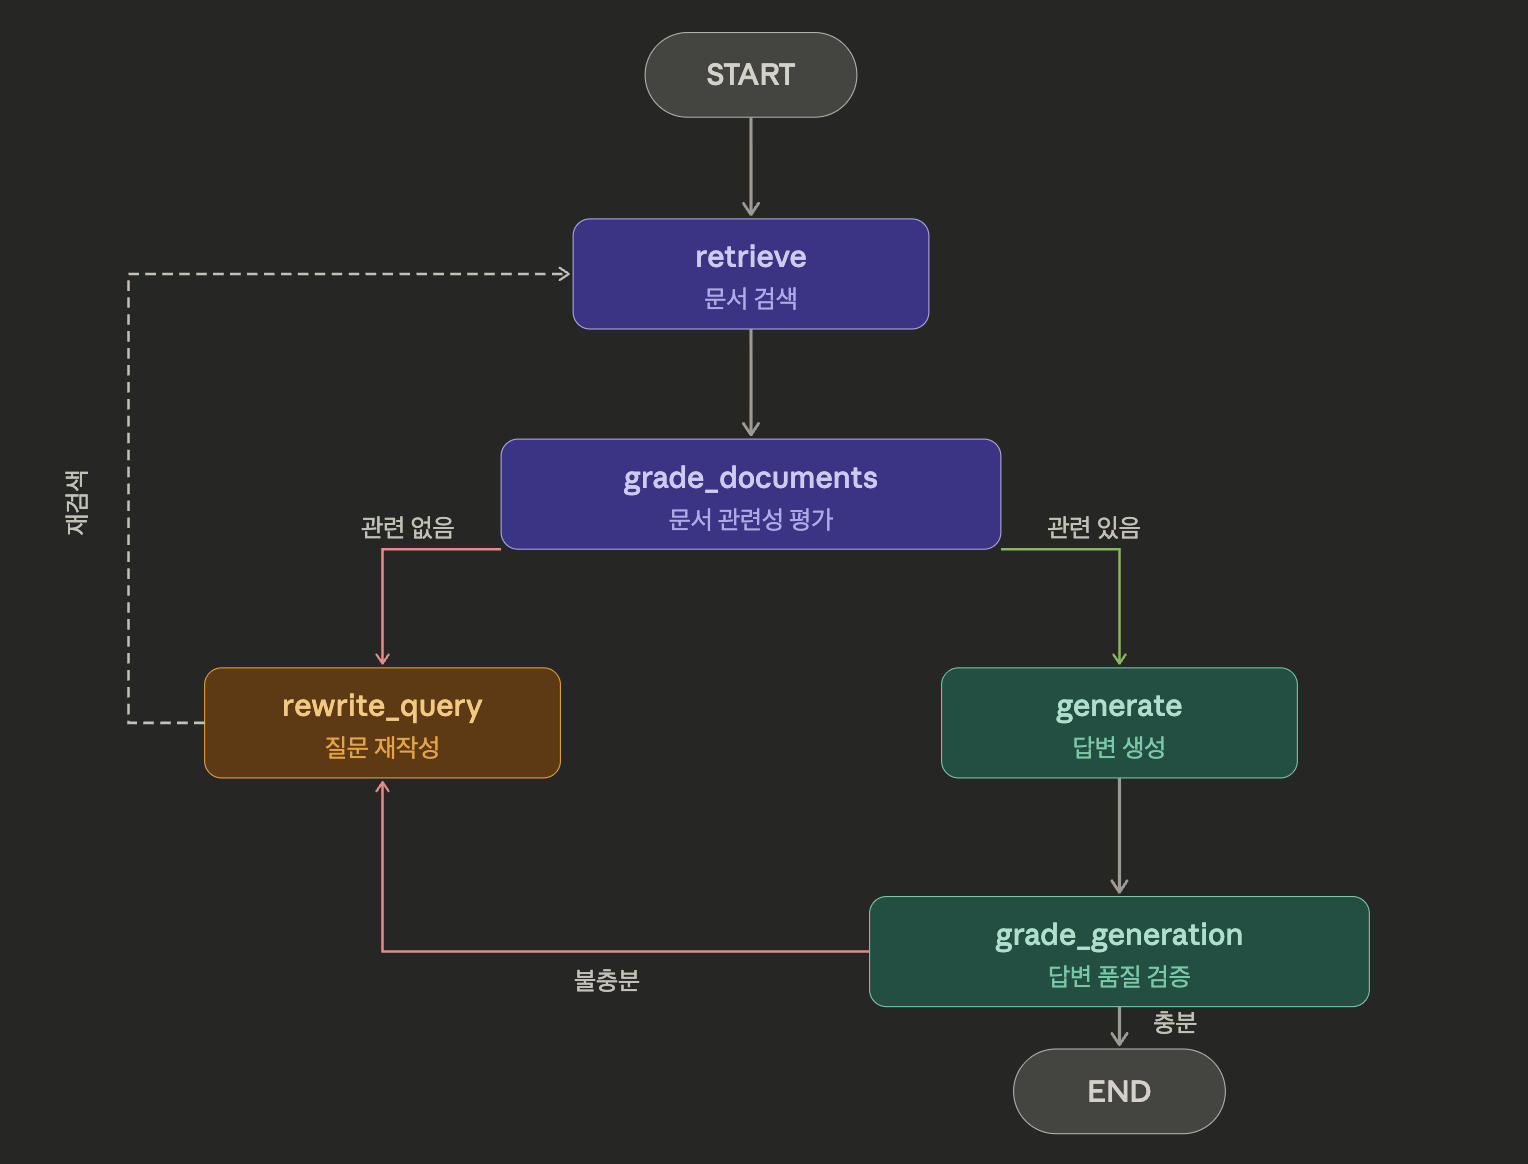

State 필드:
- `question`: 현재 질문 (재작성될 수 있음)
- `documents`: 검색된 문서
- `generation`: 생성된 답변
- `citations`: 답변의 근거가 된 문서 원문 발췌
- `relevance`: 문서 관련성 평가 결과 (bool)
- `is_sufficient`: 답변 품질 검증 결과 (bool)
- `retry_count`: 재시도 횟수 (무한 루프 방지)